![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Redes Neuronales

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de redes neuronales de una capa y multicapa. El taller está constituido por 4 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción probabilidad de admisión a la universidad

En este taller se usará el conjunto de datos de admisiones a una universidad proveniente de la base de datos de Kaggle. Cada observación contiene la probabilidad de que un estudiante sea admitido por la universidad, dadas distintas variables predictoras como el puntaje del examén TOEFL y GRE, el promedio (GPA), entre otras. El objetivo es predecir la probabilidad de admissión de cada estudiante. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/mohansacharya/graduate-admissions).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [25]:
# Importación librerías
import numpy as np
import keras 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from keras import initializers
from keras import optimizers
from keras.models import Sequential, load_model
from keras.layers import Dense
from keras.layers import Dropout
from IPython.display import Markdown, display

from livelossplot import PlotLossesKeras
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scikeras.wrappers import KerasRegressor
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [3]:
# Carga de datos de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/universityGraduateAdmissions.csv', index_col=0)
data.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
Serial No.,,,,,,,,
1,337,118,4,4.5,4.5,9.65,1,0.92
2,324,107,4,4.0,4.5,8.87,1,0.76
3,316,104,3,3.0,3.5,8.00,1,0.72
4,322,110,3,3.5,2.5,8.67,1,0.80
5,314,103,2,2.0,3.0,8.21,0,0.65


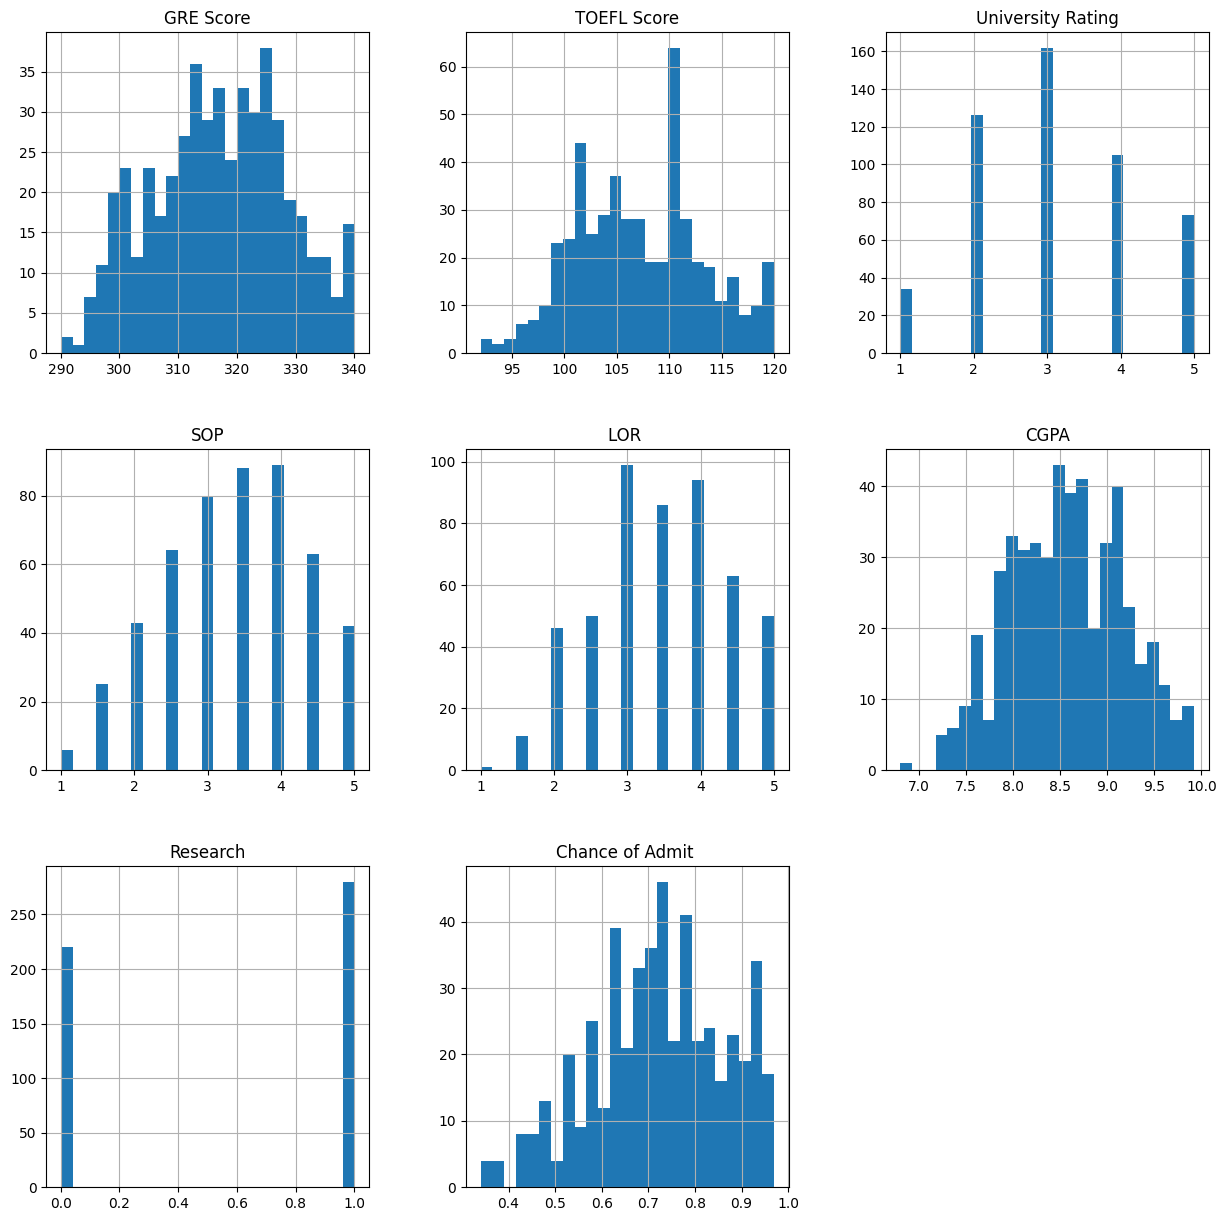

In [4]:
# Hitogramas de las varaibles del dataset
data.hist(bins=25, figsize=(15,15))
plt.show()

In [5]:
# Definición de variables predictoras (X)
X = data.drop(data.columns[-1], axis=1)
# Definición de variable de interés (y)
Y = data[data.columns[-1]]

In [6]:
# Separación de variables predictoras (X) y variable de interés (y) en set de entrenamiento y test usandola función train_test_split
xTrain, xTest, yTrain, yTest = train_test_split(X,Y,test_size=0.3, random_state=22)

In [7]:
#Escalamiento de los datos
scaler = StandardScaler()
scaler.fit(X)

# Transformación de los set de entrenamiento y test
X_train = pd.DataFrame(data=scaler.transform(xTrain), columns=xTrain.columns, index=xTrain.index)
X_test = pd.DataFrame(data=scaler.transform(xTest), columns=xTest.columns, index=xTest.index)

X_train = np.array(X_train)
Y_train = np.array(yTrain)

X_test = np.array(X_test)
Y_test = np.array(yTest)

# Definición de dimensiones de salida, varaibles de interés
output_var = 1
print(output_var, ' output variables')

# Definición de dimensiones de entrada, varaibles predictoras
dims = X_train.shape[1]
print(dims, 'input variables')

1  output variables
7 input variables


## Punto 1 - Red Neuronal de una capa

En la celda 1 creen una **red neuronal de una capa** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes, usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador y el número de épocas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

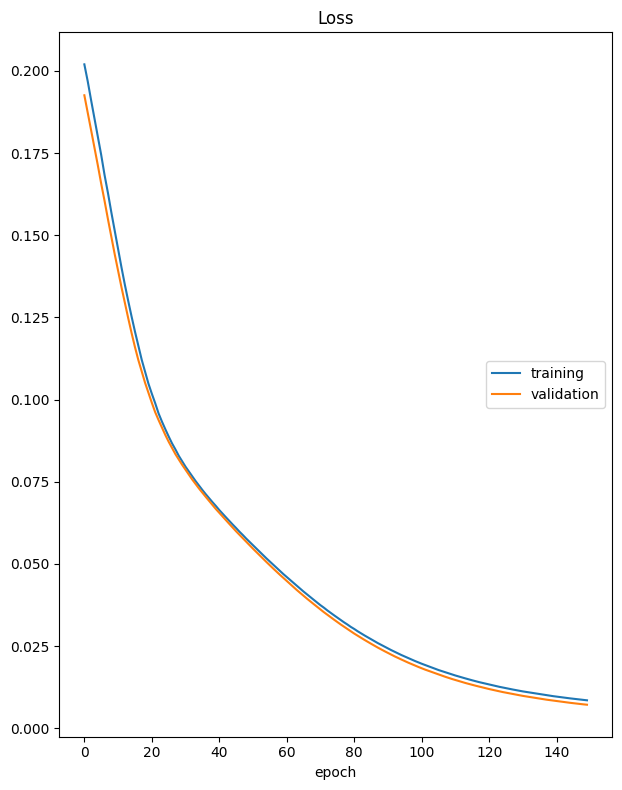

Loss
	training         	 (min:    0.009, max:    0.202, cur:    0.009)
	validation       	 (min:    0.007, max:    0.193, cur:    0.007)
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0085 - val_loss: 0.0072
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

Mejor desempeño: -0.07587674306542551
Mejores parámetros: {'epochs': 150, 'loss': 'mean_squared_error', 'optimizer': 'adam'}
Error Absoluto Medio (MAE): 0.0663
Error Cuadrático Medio (MSE): 0.0072


In [8]:
# Celda 1
def crear_modelo_una_capa(optimizer='adam', loss='mean_squared_error'):
    model = Sequential()
    model.add(Dense(output_var, input_shape=(dims,), activation='sigmoid'))
    model.compile(optimizer=optimizer, loss=loss)
    return model

model_wrapper = KerasRegressor(model=crear_modelo_una_capa, verbose=0)

param_grid = {
    'optimizer': ['adam', 'sgd', 'rmsprop'],
    'loss': ['mean_squared_error', 'binary_crossentropy'],
    'epochs': [50, 100, 150],
}

grid = GridSearchCV(estimator=model_wrapper, param_grid=param_grid, cv=3, scoring='neg_mean_absolute_error')
grid_result = grid.fit(X_train, Y_train)

best_config = grid_result.best_params_
model_final = crear_modelo_una_capa(optimizer=best_config['optimizer'], loss=best_config['loss'])
model_final.fit(X_train, Y_train, epochs=best_config['epochs'], validation_data=(X_test, Y_test), verbose=1, callbacks=[PlotLossesKeras()])

y_pred = model_final.predict(X_test)
mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)

print(f"\nMejor desempeño: {grid_result.best_score_}")
print(f"Mejores parámetros: {grid_result.best_params_}")

print(f"Error Absoluto Medio (MAE): {mae:.4f}")
print(f"Error Cuadrático Medio (MSE): {mse:.4f}")

## Punto 2 - Red Neuronal multicapa

En la celda 2 creen una **red neuronal con dos capas** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

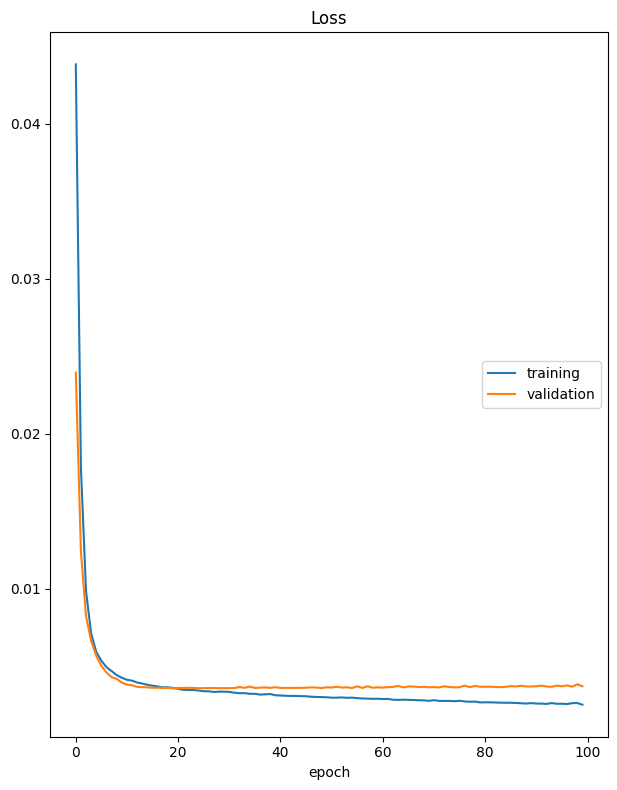

Loss
	training         	 (min:    0.003, max:    0.044, cur:    0.003)
	validation       	 (min:    0.004, max:    0.024, cur:    0.004)
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0025 - val_loss: 0.0037
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Mejor desempeño: -0.04646862630657789
Mejores parámetros: {'epochs': 100, 'loss': 'mean_squared_error', 'model__num_neuronas': 128, 'optimizer': 'adam'}
Error Absoluto Medio (MAE): 0.0439
Error Cuadrático Medio (MSE): 0.0037


In [9]:
# Celda 2
def crear_modelo_dos_capas(optimizer='adam', loss='mean_squared_error', num_neuronas=256):
    model = Sequential()
    model.add(Dense(num_neuronas, input_shape=(dims,), activation='relu'))
    model.add(Dense(output_var, activation='sigmoid'))
    model.compile(optimizer=optimizer, loss=loss)
    return model

model_wrapper_2_capas = KerasRegressor(model=crear_modelo_dos_capas, verbose=0)

param_grid_2_capas = {
    'optimizer': ['adam', 'sgd', 'rmsprop'],
    'loss': ['mean_squared_error', 'binary_crossentropy'],
    'epochs': [100, 150],
    'model__num_neuronas': [128, 256]
}

grid_2_capas = GridSearchCV(estimator=model_wrapper_2_capas, param_grid=param_grid_2_capas, cv=3, scoring='neg_mean_absolute_error')
grid_result_2_capas = grid_2_capas.fit(X_train, Y_train)

best_config_2_capas = grid_result_2_capas.best_params_
model_final_2_capas = crear_modelo_dos_capas(optimizer=best_config_2_capas['optimizer'], loss=best_config_2_capas['loss'], num_neuronas=best_config_2_capas['model__num_neuronas'])
model_final_2_capas.fit(X_train, Y_train, epochs=best_config_2_capas['epochs'], validation_data=(X_test, Y_test), verbose=1, callbacks=[PlotLossesKeras()])

y_pred_2_capas = model_final_2_capas.predict(X_test)
mae_2_capas = mean_absolute_error(Y_test, y_pred_2_capas)
mse_2_capas = mean_squared_error(Y_test, y_pred_2_capas)

print(f"\nMejor desempeño: {grid_result_2_capas.best_score_}")
print(f"Mejores parámetros: {grid_result_2_capas.best_params_}")

print(f"Error Absoluto Medio (MAE): {mae_2_capas:.4f}")
print(f"Error Cuadrático Medio (MSE): {mse_2_capas:.4f}")

## Punto 3  - Red Neuronal multicapa

En la celda 3 creen **una red neuronal con más de una capa con la librería Keras, usando early stopping y dropout,** que prediga la probabilidad de admisión de los estudiantes con los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

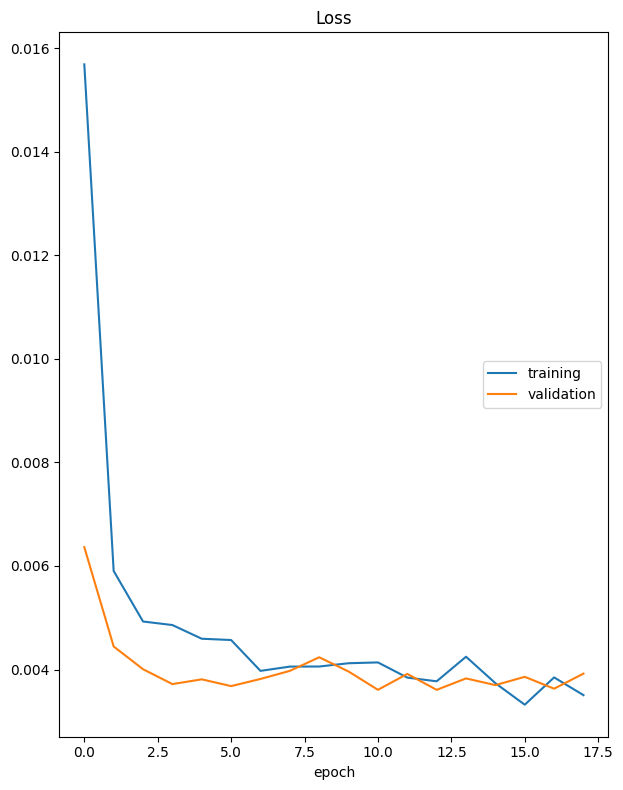

Loss
	training         	 (min:    0.003, max:    0.016, cur:    0.004)
	validation       	 (min:    0.004, max:    0.006, cur:    0.004)
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0035 - val_loss: 0.0039


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

Mejor desempeño: -0.05994369467919298
Mejores parámetros: {'loss': 'mean_squared_error', 'model__num_neuronas': 256, 'optimizer': 'rmsprop'}
Error Absoluto Medio (MAE): 0.0442
Error Cuadrático Medio (MSE): 0.0036


In [10]:
# Celda 3
def crear_modelo_multi_capa(optimizer='adam', loss='mean_squared_error', num_neuronas=256):
    model = Sequential()
    model.add(Dense(num_neuronas, input_shape=(dims,), activation='relu'))
    model.add(Dropout(0.2))

    model.add(Dense(num_neuronas,activation='relu'))
    model.add(Dropout(0.1))

    model.add(Dense(output_var, activation='sigmoid'))

    model.compile(optimizer=optimizer, loss=loss)
    return model

model_wrapper_multi = KerasRegressor(model=crear_modelo_multi_capa, verbose=0)

param_grid_multi = {
    'optimizer': ['adam', 'sgd', 'rmsprop'],
    'loss': ['mean_squared_error', 'binary_crossentropy'],
    'model__num_neuronas': [128, 256]
}

early_stop = EarlyStopping(monitor='val_loss', patience=5, verbose=0) 
fBestModel = 'best_model.h5'
best_model = ModelCheckpoint(fBestModel, verbose=0, save_best_only=True)

grid_multi = GridSearchCV(estimator=model_wrapper_multi, param_grid=param_grid_multi, cv=3, scoring='neg_mean_absolute_error')
grid_result_multi = grid_multi.fit(X_train, Y_train, validation_data=(X_test, Y_test), callbacks=[early_stop])
best_config_multi = grid_result_multi.best_params_

model_final_multi = crear_modelo_multi_capa(optimizer=best_config_multi['optimizer'], loss=best_config_multi['loss'], num_neuronas=best_config_multi['model__num_neuronas'])
model_final_multi.fit(X_train, Y_train, epochs=300, validation_data=(X_test, Y_test), verbose=1, callbacks=[best_model, early_stop, PlotLossesKeras()])
mejor_modelo = load_model('best_model.h5')

y_pred_multi = mejor_modelo.predict(X_test)
mae_multi = mean_absolute_error(Y_test, y_pred_multi)
mse_multi = mean_squared_error(Y_test, y_pred_multi)

print(f"\nMejor desempeño: {grid_result_multi.best_score_}")
print(f"Mejores parámetros: {grid_result_multi.best_params_}")

print(f"Error Absoluto Medio (MAE): {mae_multi:.4f}")
print(f"Error Cuadrático Medio (MSE): {mse_multi:.4f}")

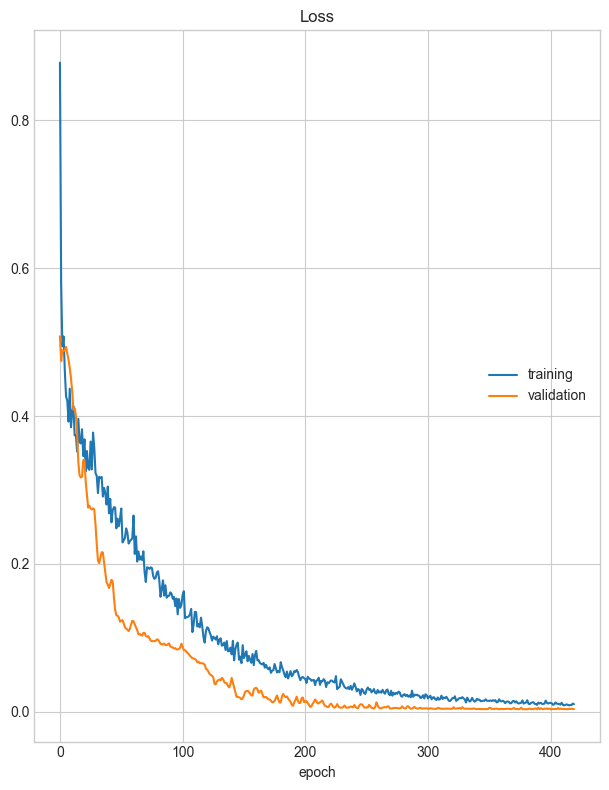

Loss
	training         	 (min:    0.009, max:    0.878, cur:    0.010)
	validation       	 (min:    0.003, max:    0.508, cur:    0.004)
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0103 - val_loss: 0.0037


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Mejor desempeño CV: -0.1096
Mejores parámetros: {'model__dropout_rate': 0.15, 'model__lr': 0.0005, 'model__num_layers': 3, 'model__num_neuronas': 96}
Error Absoluto Medio (MAE): 0.0449
Error Cuadrático Medio (MSE): 0.0034


In [16]:
# Celda 3 - versión 6 (regresión: salida linear, sin ReduceLR, batch más grande)
from keras.optimizers import Adam
from keras.layers import BatchNormalization

def crear_modelo_multi_capa(num_neuronas=64, num_layers=3, lr=5e-4,
                            dropout_rate=0.2, loss='mean_squared_error'):
    model = Sequential()
    model.add(Dense(num_neuronas, input_shape=(dims,), activation='relu',
                    kernel_initializer='he_normal'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))

    for _ in range(num_layers - 1):
        model.add(Dense(num_neuronas, activation='relu',
                        kernel_initializer='he_normal'))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate * 0.75))

    model.add(Dense(output_var, activation='relu'))
    model.compile(optimizer=Adam(learning_rate=lr), loss=loss)
    return model

model_wrapper_multi = KerasRegressor(
    model=crear_modelo_multi_capa,
    epochs=200,
    batch_size=64,
    verbose=0,
)

param_grid_multi = {
    'model__num_neuronas': [48, 64, 96],
    'model__num_layers':   [3, 4],
    'model__dropout_rate': [0.15, 0.2, 0.25],
    'model__lr':           [5e-4, 3e-4],
}

early_stop = EarlyStopping(
    monitor='val_loss', patience=30,
    restore_best_weights=True, verbose=0,
)
fBestModel = 'best_model.h5'
best_model = ModelCheckpoint(fBestModel, verbose=0, save_best_only=True)

grid_multi = GridSearchCV(
    estimator=model_wrapper_multi,
    param_grid=param_grid_multi,
    cv=3,
    scoring='neg_mean_absolute_error',
)
grid_result_multi = grid_multi.fit(X_train, Y_train)
best_config_multi = grid_result_multi.best_params_

model_final_multi = crear_modelo_multi_capa(
    num_neuronas=best_config_multi['model__num_neuronas'],
    num_layers=best_config_multi['model__num_layers'],
    dropout_rate=best_config_multi['model__dropout_rate'],
    lr=best_config_multi['model__lr'],
)
model_final_multi.fit(
    X_train, Y_train,
    epochs=500,
    batch_size=64,
    validation_data=(X_test, Y_test),
    verbose=1,
    callbacks=[best_model, early_stop, PlotLossesKeras()],
)
mejor_modelo2 = load_model('best_model.h5')

y_pred_multi = mejor_modelo2.predict(X_test)
mae_multi2 = mean_absolute_error(Y_test, y_pred_multi)
mse_multi2 = mean_squared_error(Y_test, y_pred_multi)

print(f"\nMejor desempeño CV: {grid_result_multi.best_score_:.4f}")
print(f"Mejores parámetros: {grid_result_multi.best_params_}")
print(f"Error Absoluto Medio (MAE): {mae_multi2:.4f}")
print(f"Error Cuadrático Medio (MSE): {mse_multi2:.4f}")

## Punto 4 - Comparación y análisis de resultados

En la celda 4 comparen los resultados obtenidos de las diferentes redes y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

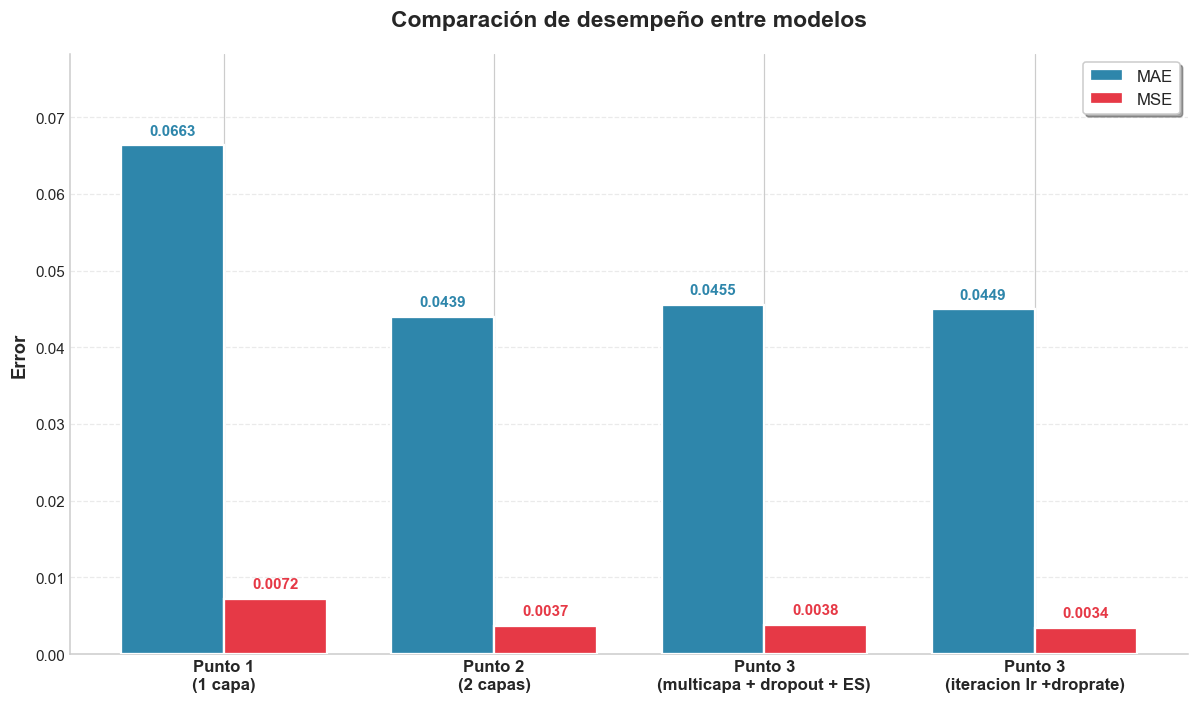


═══════════════════════════════════════════════════════
                 Resumen de desempeño                  
═══════════════════════════════════════════════════════
Modelo                                   MAE      MSE
───────────────────────────────────────────────────────
Punto 1 (1 capa)                      0.0663   0.0072  
Punto 2 (2 capas)                     0.0439   0.0037 ★
Punto 3 (multicapa + dropout + ES)    0.0455   0.0038  
Punto 3 (iteracion lr +droprate)      0.0449   0.0034  
═══════════════════════════════════════════════════════


In [ ]:
# Celda 4
modelos = ['Punto 1\n(1 capa)', 'Punto 2\n(2 capas)', 'Punto 3\n(multicapa + dropout + ES)', 'Punto 3\n(iteracion lr +droprate)']
mae_vals = [mae, mae_2_capas, mae_multi,mae_multi2]
mse_vals = [mse, mse_2_capas, mse_multi,mse_multi2]
mejor_idx = int(np.argmin(mae_vals))

x = np.arange(len(modelos))
ancho = 0.38

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(11, 6.5), dpi=110)

color_mae = '#2E86AB'
color_mse = '#E63946'

barras_mae = ax.bar(x - ancho/2, mae_vals, ancho, label='MAE',
                    color=color_mae, edgecolor='white', linewidth=1.5, zorder=3)
barras_mse = ax.bar(x + ancho/2, mse_vals, ancho, label='MSE',
                    color=color_mse, edgecolor='white', linewidth=1.5, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=11, fontweight='bold')
ax.set_ylabel('Error', fontsize=12, fontweight='bold')
ax.set_title('Comparación de desempeño entre modelos',
             fontsize=15, fontweight='bold', pad=18)
ax.legend(fontsize=11, loc='upper right', frameon=True,
          fancybox=True, shadow=True)
ax.grid(axis='y', alpha=0.4, linestyle='--', zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', labelsize=10)
ax.set_ylim(0, max(max(mae_vals), max(mse_vals)) * 1.18)


for barras, color in [(barras_mae, color_mae), (barras_mse, color_mse)]:
    for b in barras:
        h = b.get_height()
        ax.annotate(f'{h:.4f}',
                    xy=(b.get_x() + b.get_width() / 2, h),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold', color=color)


plt.tight_layout()
plt.show()

# Tabla resumen
print("\n" + "═" * 55)
print(f"{'Resumen de desempeño':^55}")
print("═" * 55)
print(f"{'Modelo':<35} {'MAE':>8} {'MSE':>8}")
print("─" * 55)
for nombre, m, s in zip(modelos, mae_vals, mse_vals):
    nombre_plano = nombre.replace('\n', ' ')
    marca = ' ★' if mae_vals.index(m) == mejor_idx else '  '
    print(f"{nombre_plano:<35} {m:>8.4f} {s:>8.4f}{marca}")
print("═" * 55)

In [37]:
display(Markdown(f"""**Conclusión:** Inicialmente se evaluaron los modelos con 2 metricas, MAE y MSE, para tener una visión más completa del desempeño. Sin embargo, 
                 dado que el MAE es más interpretable, cada punto representa una unidad de error promedio en la misma escala de la variable objetivo. Además, el problema no enfrenta outliers severos, 
                 lo que hace que no sea necesario penalizar errores grandes como lo haría el MSE. Se optó por el MAE como métrica principal para determinar el mejor modelo. Teniendo 
                 esto en cuenta, el mejor modelo es **{modelos[mejor_idx]}** con un valor de **{mae_vals[mejor_idx]:.4f}**. Esto se interpreta como que, en promedio, 
                 el modelo comete un error de aproximadamente **{mae_vals[mejor_idx]:.4f}** unidades al predecir la probabilidad de admisión. Seguido de este modelo, 
                 el modelo del punto 3 con iteración de learning rate y ajuste de dropout, mostró un desempeño muy cercano con un MAE de **{mae_multi2:.4f}** muy parecido al otro modelo del punto 
                 3 con multicapa, dropout y early stopping fijos con MAE de **{mae_multi:.4f}**. En cuanto a estos modelos, al ser un dataset con solo 500 datos, la adición de capas 
                 adicionales, regularización y optimización de hiperparámetros no ayuda a mejorar en gran medida el desempeño ya que un modelo simple como el de 2 capas logra capturar la mayor parte de las 
                 relaciones entre las variables, además de que aumentar la complejidad sobre un dataset tan pequeño incrementa el riesgo de sobreajuste. Por lo que complejizar el modelo con más capas, ajuste de dropout y learning rate no 
                 aporta una mejora significativa. Por otro lado el peor modelo es el modelo de una sola capa, lo que sugiere que un modelo demasiado simple no es 
                 capaz de capturar las relaciones entre las variables predictoras y la variable de interés. Por lo tanto, se puede concluir que un modelo con una arquitectura 
                 moderada, como el modelo de 2 capas, es suficiente para capturar las relaciones en este dataset específico y no es necesario complejizar el modelo con más capas, 
                 ajuste de dropout o learning rate para obtener un mejor desempeño.
                 
                 \n Por otra parte, se sustenta que los modelos son muy parecidos debido a que al analizar el MSE el mejor modelo ya no sería el de 2 capas sino el multicapa con
                 iteración de learning rate y ajuste de dropout, lo que sugiere que este modelo al usar dropout intenta evitar el sobreajuste, por lo que predice un poco peor en promedio teniendo 
                 mayor MAE pero evitando dar predicciones muy alejadas disminuyendo el MSE. Además, al ser un error muy pequeño en ambos modelos permite indicar que ambos modelos tienen un desempeño 
                 muy similar, y que la elección entre ellos podría basarse en otros factores como la interpretabilidad, la eficiencia computacional o la preferencia por un modelo más simple 
                 frente a uno más complejo. En este caso, dado que el modelo de 2 capas es más simple y tiene un MAE ligeramente mejor, podría ser la opción preferida para este dataset específico o de igual
                 forma se podría elegir el del punto 3 ya que con los controles de regularización, a la larga al haber más datos, podría evitar un sobreajuste si este modelo inicial quedó demasiado 
                 ajustado a los datos de entrenamiento. En resumen, ambos modelos son opciones válidas y la elección entre ellos dependerá de las prioridades y consideraciones 
                 específicas del caso de uso."""))

**Conclusión:** Inicialmente se evaluaron los modelos con 2 metricas, MAE y MSE, para tener una visión más completa del desempeño. Sin embargo, 
                 dado que el MAE es más interpretable, cada punto representa una unidad de error promedio en la misma escala de la variable objetivo. Además, el problema no enfrenta outliers severos, 
                 lo que hace que no sea necesario penalizar errores grandes como lo haría el MSE. Se optó por el MAE como métrica principal para determinar el mejor modelo. Teniendo 
                 esto en cuenta, el mejor modelo es **Punto 2
(2 capas)** con un valor de **0.0439**. Esto se interpreta como que, en promedio, 
                 el modelo comete un error de aproximadamente **0.0439** unidades al predecir la probabilidad de admisión. Seguido de este modelo, 
                 el modelo del punto 3 con iteración de learning rate y ajuste de dropout, mostró un desempeño muy cercano con un MAE de **0.0449** muy parecido al otro modelo del punto 
                 3 con multicapa, dropout y early stopping fijos con MAE de **0.0455**. En cuanto a estos modelos, al ser un dataset con solo 500 datos, la adición de capas 
                 adicionales, regularización y optimización de hiperparámetros no ayuda a mejorar en gran medida el desempeño ya que un modelo simple como el de 2 capas logra capturar la mayor parte de las 
                 relaciones entre las variables, además de que aumentar la complejidad sobre un dataset tan pequeño incrementa el riesgo de sobreajuste. Por lo que complejizar el modelo con más capas, ajuste de dropout y learning rate no 
                 aporta una mejora significativa. Por otro lado el peor modelo es el modelo de una sola capa, lo que sugiere que un modelo demasiado simple no es 
                 capaz de capturar las relaciones entre las variables predictoras y la variable de interés. Por lo tanto, se puede concluir que un modelo con una arquitectura 
                 moderada, como el modelo de 2 capas, es suficiente para capturar las relaciones en este dataset específico y no es necesario complejizar el modelo con más capas, 
                 ajuste de dropout o learning rate para obtener un mejor desempeño.
                 
                 
 Por otra parte, se sustenta que los modelos son muy parecidos debido a que al analizar el MSE el mejor modelo ya no sería el de 2 capas sino el multicapa con
                 iteración de learning rate y ajuste de dropout, lo que sugiere que este modelo al usar dropout intenta evitar el sobreajuste, por lo que predice un poco peor en promedio teniendo 
                 mayor MAE pero evitando dar predicciones muy alejadas disminuyendo el MSE. Además, al ser un error muy pequeño en ambos modelos permite indicar que ambos modelos tienen un desempeño 
                 muy similar, y que la elección entre ellos podría basarse en otros factores como la interpretabilidad, la eficiencia computacional o la preferencia por un modelo más simple 
                 frente a uno más complejo. En este caso, dado que el modelo de 2 capas es más simple y tiene un MAE ligeramente mejor, podría ser la opción preferida para este dataset específico o de igual
                 forma se podría elegir el del punto 3 ya que con los controles de regularización, a la larga al haber más datos, podría evitar un sobreajuste si este modelo inicial quedó demasiado 
                 ajustado a los datos de entrenamiento. En resumen, ambos modelos son opciones válidas y la elección entre ellos dependerá de las prioridades y consideraciones 
                 específicas del caso de uso.